# CREDIT CARD FRAUD DETECTION

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


1. Load the dataset

In [5]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("Class distribution:\n", df['Class'].value_counts())

Shape: (284807, 31)
Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


2. Scale Amount and Time

In [6]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

3. Features & Target

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

4. Split first, then SMOTE only on train set

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

5. Handle class imbalance with SMOTE

In [9]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train_res).value_counts())

After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


6. Train the model

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

7. Evaluate the modell


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



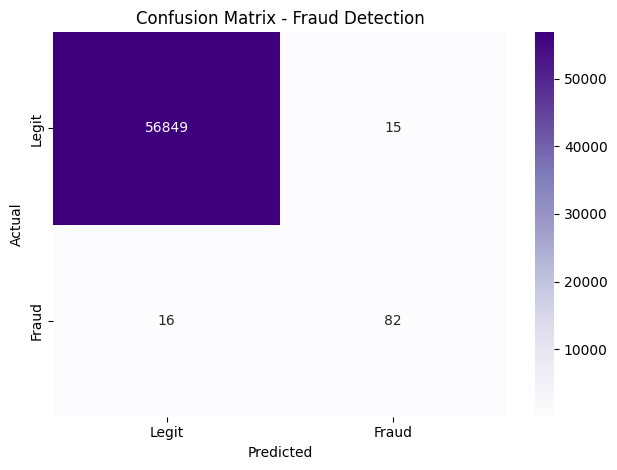

In [11]:
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("Confusion Matrix - Fraud Detection")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("fraud_confusion_matrix.png")
plt.show()